# AI for Communication and Marketing – Lab Exam Part 3


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

!pip install lifetimes
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import calibration_and_holdout_data
from lifetimes.plotting import plot_frequency_recency_matrix, plot_probability_alive_matrix

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

PATH = '/content/'
print('Libraries loaded successfully')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 10.9 MB/s eta 0:00:00
Libraries loaded successfully


---
## Task A – Data Audit & Cleaning

### A1. Load & Merge Tables

In [2]:
orders    = pd.read_csv(PATH + 'olist_orders_dataset.csv')
customers = pd.read_csv(PATH + 'olist_customers_dataset.csv')
payments  = pd.read_csv(PATH + 'olist_order_payments_dataset.csv')
items     = pd.read_csv(PATH + 'olist_order_items_dataset.csv')

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

print('orders shape:   ', orders.shape)
print('customers shape:', customers.shape)
print('payments shape: ', payments.shape)
print('items shape:    ', items.shape)
print('\nOrder status distribution:')
print(orders['order_status'].value_counts())

orders shape:    (99441, 8)
customers shape: (99441, 5)
payments shape:  (103886, 5)
items shape:     (112650, 7)

Order status distribution:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


### A2. Filter Invalid Transactions

In [3]:
# Kept only delivered orders : cancelled/unavailable/processing orders are not valid revenue
before = len(orders)
orders = orders[orders['order_status'] == 'delivered']
print(f'Removed {before - len(orders)} non-delivered orders')
print(f'Remaining orders: {len(orders)}')

Removed 2963 non-delivered orders
Remaining orders: 96478


### A3. Aggregate & Merge

In [4]:
# Some orders have multiple payment rows (installments) — sum them per order
pay_agg = payments.groupby('order_id')['payment_value'].sum().reset_index()

# Merge: orders + payments + customers
df = orders.merge(pay_agg, on='order_id', how='inner')
df = df.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='inner')

# Keep only relevant columns and rename
df = df[['customer_unique_id', 'order_purchase_timestamp', 'payment_value']]
df.columns = ['customer_id', 'order_date', 'order_value']

print('Merged dataset shape:', df.shape)
print('Missing values:', df.isnull().sum().sum())

Merged dataset shape: (96477, 3)
Missing values: 0


### A4. Handle Outliers & Zero Values

In [5]:
# Remove zero or negative order values — these are invalid transactions
before = len(df)
df = df[df['order_value'] > 0]
print(f'Removed {before - len(df)} zero/negative value orders')

# Cap extreme outliers at 99th percentile
cap_99 = df['order_value'].quantile(0.99)
before = len(df)
df = df[df['order_value'] <= cap_99]
print(f'Removed {before - len(df)} extreme outlier orders (> R${cap_99:.2f})')

print(f'\nFinal transactions: {len(df)}')
print(f'Unique customers:   {df["customer_id"].nunique()}')
print(f'Date range: {df["order_date"].min().date()} to {df["order_date"].max().date()}')
print(f'\nOrder value stats:')
print(df['order_value'].describe().round(2))

Removed 0 zero/negative value orders
Removed 965 extreme outlier orders (> R$1052.39)

Final transactions: 95512
Unique customers:   92419
Date range: 2016-10-03 to 2018-08-29

Order value stats:
count    95512.00
mean       144.68
std        137.36
min          9.59
25%         61.64
50%        104.12
75%        173.53
max       1052.36
Name: order_value, dtype: float64


### A5. Cleaning Summary

| Issue | Action | Reason |
|---|---|---|
| Non-delivered orders (cancelled, unavailable etc.) | Removed | Only delivered orders represent real revenue |
| Multiple payment rows per order | Aggregated (sum) | Installment payments split into multiple rows |
| `customer_id` vs `customer_unique_id` | Replaced with unique ID | Same customer can appear with multiple order-level IDs |
| Zero/negative order values | Removed | Invalid transactions |
| Extreme outliers in order value (>99th pct) | Removed | Distort CLTV estimates |

---
## Task B – Exploratory Data Analysis (EDA)

### B1. Distribution of Purchase Frequency, Recency & Spend

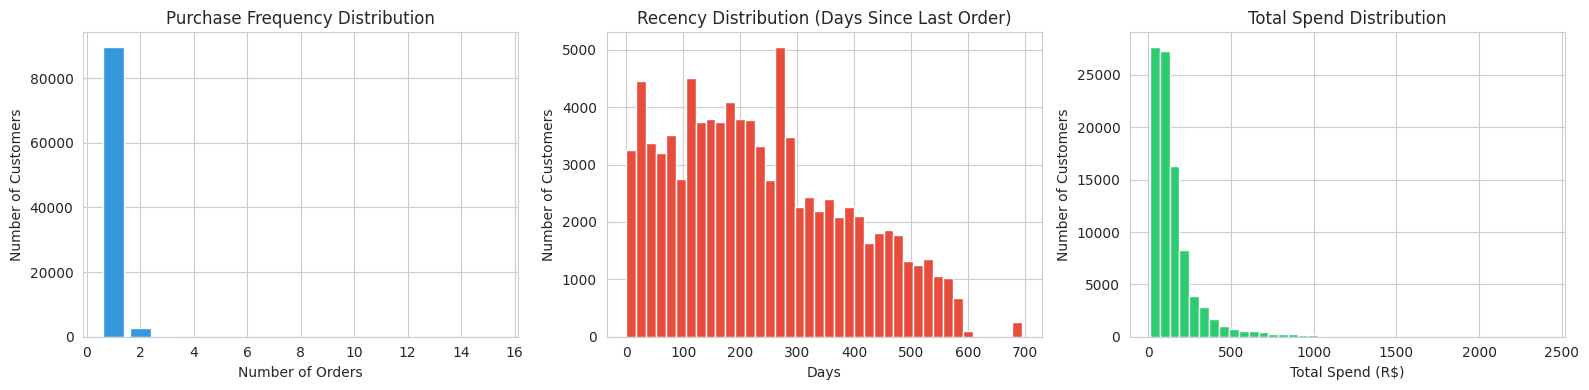

One-time buyers: 89642 (97.0%)
Repeat buyers:   2777 (3.0%)


In [6]:
# Customer-level summary
customer_summary = df.groupby('customer_id').agg(
    num_orders=('order_date', 'count'),
    total_spend=('order_value', 'sum'),
    first_order=('order_date', 'min'),
    last_order=('order_date', 'max')
).reset_index()

obs_end = df['order_date'].max()
customer_summary['recency_days'] = (obs_end - customer_summary['last_order']).dt.days

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Purchase frequency
freq_counts = customer_summary['num_orders'].value_counts().sort_index().head(10)
axes[0].bar(freq_counts.index, freq_counts.values, color='#3498db')
axes[0].set_title('Purchase Frequency Distribution')
axes[0].set_xlabel('Number of Orders')
axes[0].set_ylabel('Number of Customers')

# Recency
axes[1].hist(customer_summary['recency_days'], bins=40, color='#e74c3c', edgecolor='white')
axes[1].set_title('Recency Distribution (Days Since Last Order)')
axes[1].set_xlabel('Days')
axes[1].set_ylabel('Number of Customers')

# Total spend
axes[2].hist(customer_summary['total_spend'], bins=40, color='#2ecc71', edgecolor='white')
axes[2].set_title('Total Spend Distribution')
axes[2].set_xlabel('Total Spend (R$)')
axes[2].set_ylabel('Number of Customers')

plt.tight_layout()
plt.show()

one_time = (customer_summary['num_orders'] == 1).sum()
total = len(customer_summary)
print(f'One-time buyers: {one_time} ({one_time/total*100:.1f}%)')
print(f'Repeat buyers:   {total - one_time} ({(total-one_time)/total*100:.1f}%)')

### B2. RFM Feature Engineering + T (Customer Tenure)

In [7]:
# Define calibration and holdout periods
# Calibration: Oct 2016 – Jun 2018 (train models)
# Holdout:     Jul 2018 – Aug 2018 (validate predictions ~90 days)
CAL_END  = pd.Timestamp('2018-06-30')
HOLD_END = df['order_date'].max()

print(f'Calibration period: {df["order_date"].min().date()} → {CAL_END.date()}')
print(f'Holdout period:     {(CAL_END + pd.Timedelta(days=1)).date()} → {HOLD_END.date()}')

# Build RFM + T summary using lifetimes calibration_and_holdout_data
# T = time from first purchase to end of calibration period (customer tenure)
rfm_cal_holdout = calibration_and_holdout_data(
    df,
    customer_id_col='customer_id',
    datetime_col='order_date',
    monetary_value_col='order_value',
    calibration_period_end=CAL_END,
    observation_period_end=HOLD_END,
    freq='D'
)

print(f'\nRFM calibration/holdout shape: {rfm_cal_holdout.shape}')
print('\nColumn descriptions:')
print('  frequency_cal  = repeat purchases in calibration period')
print('  recency_cal    = days between first and last purchase (calibration)')
print('  T_cal          = days from first purchase to end of calibration (tenure)')
print('  monetary_value = avg order value in calibration period')
print('  frequency_holdout = actual purchases in holdout period')
print(rfm_cal_holdout.head())

Calibration period: 2016-10-03 → 2018-06-30
Holdout period:     2018-07-01 → 2018-08-29

RFM calibration/holdout shape: (80333, 7)

Column descriptions:
  frequency_cal  = repeat purchases in calibration period
  recency_cal    = days between first and last purchase (calibration)
  T_cal          = days from first purchase to end of calibration (tenure)
  monetary_value = avg order value in calibration period
  frequency_holdout = actual purchases in holdout period
                                  frequency_cal  recency_cal  T_cal  \
customer_id                                                           
0000366f3b9a7992bf8c76cfdf3221e2            0.0          0.0   51.0   
0000b849f77a49e4a4ce2b2a4ca5be3f            0.0          0.0   54.0   
0000f46a3911fa3c0805444483337064            0.0          0.0  477.0   
0000f6ccb0745a6a4b88665a16c9f078            0.0          0.0  261.0   
0004aac84e0df4da2b147fca70cf8255            0.0          0.0  228.0   

                                

---
## Task C – Modeling & Evaluation

### C1. Probabilistic Model – BG/NBD (Buy Till You Die)

In [8]:
# BG/NBD models two processes simultaneously:
# 1. How often a customer buys (NBD - Negative Binomial Distribution)
# 2. When a customer becomes inactive / "dies" (BG - Beta-Geometric)

bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(
    rfm_cal_holdout['frequency_cal'],
    rfm_cal_holdout['recency_cal'],
    rfm_cal_holdout['T_cal']
)
print('BG/NBD Model fitted successfully')
print(bgf)

BG/NBD Model fitted successfully
<lifetimes.BetaGeoFitter: fitted with 80333 subjects, a: 0.09, alpha: 71.73, b: 0.02, r: 0.02>


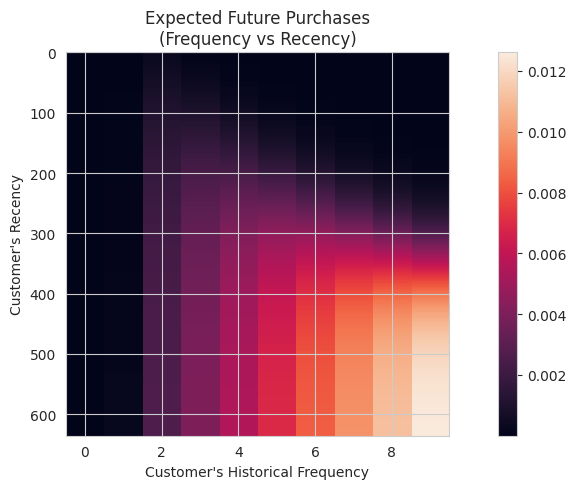

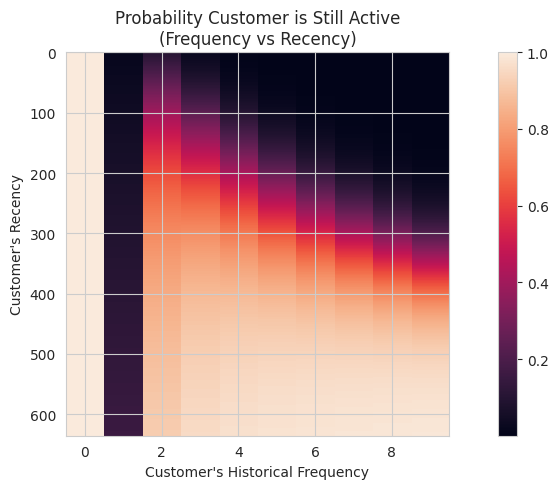

In [9]:
 # Visualise frequency-recency matrix
plot_frequency_recency_matrix(bgf)
plt.title('Expected Future Purchases\n(Frequency vs Recency)')
plt.tight_layout()
plt.show()

plot_probability_alive_matrix(bgf)
plt.title('Probability Customer is Still Active\n(Frequency vs Recency)')
plt.tight_layout()
plt.show()

In [10]:
# Predict expected purchases in holdout period
holdout_days = (HOLD_END - CAL_END).days

rfm_cal_holdout['predicted_purchases_bgnbd'] = bgf.predict(
    holdout_days,
    rfm_cal_holdout['frequency_cal'],
    rfm_cal_holdout['recency_cal'],
    rfm_cal_holdout['T_cal']
)

rfm_cal_holdout['prob_alive'] = bgf.conditional_probability_alive(
    rfm_cal_holdout['frequency_cal'],
    rfm_cal_holdout['recency_cal'],
    rfm_cal_holdout['T_cal']
)

print(f'Holdout period: {holdout_days} days')
print(rfm_cal_holdout[['frequency_cal','recency_cal','T_cal',
                         'predicted_purchases_bgnbd','prob_alive']].head(10).round(3))

Holdout period: 60 days
                                  frequency_cal  recency_cal  T_cal  \
customer_id                                                           
0000366f3b9a7992bf8c76cfdf3221e2            0.0          0.0   51.0   
0000b849f77a49e4a4ce2b2a4ca5be3f            0.0          0.0   54.0   
0000f46a3911fa3c0805444483337064            0.0          0.0  477.0   
0000f6ccb0745a6a4b88665a16c9f078            0.0          0.0  261.0   
0004aac84e0df4da2b147fca70cf8255            0.0          0.0  228.0   
0004bd2a26a76fe21f786e4fbd80607f            0.0          0.0   86.0   
00050ab1314c0e55a6ca13cf7181fecf            0.0          0.0   71.0   
00053a61a98854899e70ed204dd4bafe            0.0          0.0  122.0   
0005e1862207bf6ccc02e4228effd9a0            0.0          0.0  483.0   
0005ef4cd20d2893f0d9fbd94d3c0d97            0.0          0.0  110.0   

                                  predicted_purchases_bgnbd  prob_alive  
customer_id                                      

### C2. Gamma-Gamma Model – Average Monetary Value

In [11]:
# Gamma-Gamma assumption: monetary value and frequency must not be correlated
corr = rfm_cal_holdout[rfm_cal_holdout['frequency_cal'] > 0][['frequency_cal','monetary_value_cal']].corr()
print('Correlation between frequency and monetary value:')
print(corr.round(4))
corr_val = corr.loc['frequency_cal', 'monetary_value_cal']
if abs(corr_val) < 0.1:
    print(f'\nCorrelation = {corr_val:.3f} → Low correlation = Gamma-Gamma assumption is met')
else:
    print(f'\nCorrelation = {corr_val:.3f} → Warning: correlation may violate Gamma-Gamma assumption')

Correlation between frequency and monetary value:
                    frequency_cal  monetary_value_cal
frequency_cal               1.000               0.016
monetary_value_cal          0.016               1.000

Correlation = 0.016 → Low correlation = Gamma-Gamma assumption is met


In [12]:
# Fit Gamma-Gamma model on repeat buyers only (frequency > 0)
repeat_buyers = rfm_cal_holdout[rfm_cal_holdout['frequency_cal'] > 0]

ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(
    repeat_buyers['frequency_cal'],
    repeat_buyers['monetary_value_cal']
)
print('Gamma-Gamma Model fitted successfully')
print(ggf)

Gamma-Gamma Model fitted successfully
<lifetimes.GammaGammaFitter: fitted with 1668 subjects, p: 4.13, q: 0.50, v: 3.86>


### C3. CLTV Calculation – 90 Days

In [13]:
 # Manual 90-day CLTV = expected purchases × expected avg spend
expected_purchases = bgf.predict(
      90,
      rfm_cal_holdout['frequency_cal'],
      rfm_cal_holdout['recency_cal'],
      rfm_cal_holdout['T_cal']
)

expected_avg_spend = ggf.conditional_expected_average_profit(
      rfm_cal_holdout['frequency_cal'],
      rfm_cal_holdout['monetary_value_cal']
)

# clip(lower=0): Gamma-Gamma q<1 produces negative estimates for one-time buyers — treat as R$0
rfm_cal_holdout['cltv_90d'] = (expected_purchases * expected_avg_spend).clip(lower=0)

print('90-Day CLTV Summary (R$):')
print(rfm_cal_holdout['cltv_90d'].describe().round(2))
print(f'\nEstimated total customer base value (90d): R$ {rfm_cal_holdout["cltv_90d"].sum():,.2f}')

90-Day CLTV Summary (R$):
count    80333.00
mean         0.24
std          5.05
min          0.00
25%          0.00
50%          0.00
75%          0.00
max        560.64
Name: cltv_90d, dtype: float64

Estimated total customer base value (90d): R$ 18,908.80


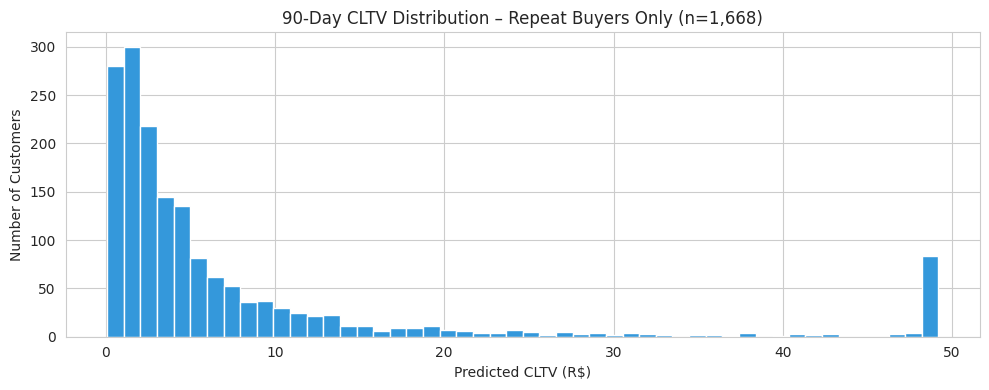

97.9% of customers have predicted CLTV = R$0
97.9% of customers have frequency_cal = 0 (only 1 purchase in calibration period)
Remaining 2.1% are repeat buyers who generate all predicted future revenue

Top 10 highest CLTV customers:
                                  frequency_cal  monetary_value_cal  \
customer_id                                                           
297ec5afd18366f5ba27520cc4954151            2.0              701.16   
397b44d5bb99eabf54ea9c2b41ebb905            3.0              489.96   
fe81bb32c243a86b2f86fbf053fe6140            4.0              381.74   
08e5b38d7948d37fbb2a59fc5e175ab1            2.0              350.72   
1da09dd64e235e7c2f29a4faff33535c            2.0              845.00   
3e43e6105506432c953e165fb2acf44c            5.0              214.79   
ca77025e7201e3b30c44b472ff346268            6.0              138.94   
86df00dc5fd68f4dd5d5945ca19f3ed6            2.0              767.94   
a029899dd8534557a81c369475ff80c8            2.0         

In [14]:
 # Show CLTV distribution for repeat buyers only (zero-CLTV customers dominate the chart otherwise)
cltv_positive = rfm_cal_holdout[rfm_cal_holdout['cltv_90d'] > 0]['cltv_90d']

plt.figure(figsize=(10, 4))
cltv_positive.clip(upper=cltv_positive.quantile(0.95)).hist(
    bins=50, color='#3498db', edgecolor='white')
plt.title(f'90-Day CLTV Distribution – Repeat Buyers Only (n={len(cltv_positive):,})')
plt.xlabel('Predicted CLTV (R$)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

pct_zero_cltv = (rfm_cal_holdout['cltv_90d'] == 0).sum() / len(rfm_cal_holdout) * 100
pct_one_time  = (rfm_cal_holdout['frequency_cal'] == 0).sum() / len(rfm_cal_holdout) * 100

print(f'{pct_zero_cltv:.1f}% of customers have predicted CLTV = R$0')
print(f'{pct_one_time:.1f}% of customers have frequency_cal = 0 (only 1 purchase in calibration period)')
print(f'Remaining {100-pct_zero_cltv:.1f}% are repeat buyers who generate all predicted future revenue')
print()
print('Top 10 highest CLTV customers:')
top10 = rfm_cal_holdout[['frequency_cal','monetary_value_cal','prob_alive','cltv_90d']].nlargest(10, 'cltv_90d')
print(top10.round(2))

### C4. Machine Learning Approach – Random Forest Regression

In [15]:
# Features from calibration period → predict actual holdout revenue
rfm_cal_holdout['actual_holdout_revenue'] = (
    rfm_cal_holdout['frequency_holdout'] * rfm_cal_holdout['monetary_value_cal']
)

features = ['frequency_cal', 'recency_cal', 'T_cal', 'monetary_value_cal']
X = rfm_cal_holdout[features]
y = rfm_cal_holdout['actual_holdout_revenue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)

# BG/NBD + Gamma-Gamma revenue prediction for the SAME test set customers
test_data = rfm_cal_holdout.loc[X_test.index]
bgf_pred_purchases = bgf.predict(
    holdout_days,
    test_data['frequency_cal'],
    test_data['recency_cal'],
    test_data['T_cal']
)
bgf_pred_spend = ggf.conditional_expected_average_profit(
    test_data['frequency_cal'],
    test_data['monetary_value_cal']
).clip(lower=0)
y_pred_bgnbd = (bgf_pred_purchases * bgf_pred_spend).values

print('Random Forest — Test Set:')
print(f'  MAE:  {mean_absolute_error(y_test, y_pred_rf):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.4f}')
print(f'  MSE:  {mean_squared_error(y_test, y_pred_rf):.4f}')

print('\nBG/NBD + Gamma-Gamma — Test Set:')
print(f'  MAE:  {mean_absolute_error(y_test, y_pred_bgnbd):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_bgnbd)):.4f}')
print(f'  MSE:  {mean_squared_error(y_test, y_pred_bgnbd):.4f}')

Random Forest — Test Set:
  MAE:  0.1082
  RMSE: 4.7010
  MSE:  22.0996

BG/NBD + Gamma-Gamma — Test Set:
  MAE:  0.1709
  RMSE: 4.8640
  MSE:  23.6588


### C5. Model Comparison – BTYD vs ML

Model Comparison — Predicting Holdout Revenue (same test set):
               Model    MAE     MSE  RMSE
BG/NBD + Gamma-Gamma 0.1709 23.6588 4.864
       Random Forest 0.1082 22.0996 4.701


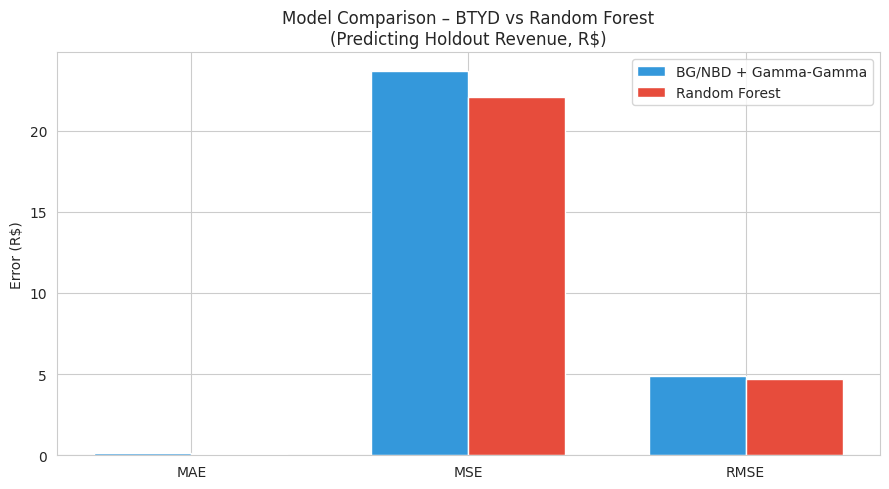

In [16]:
# Both models compared on the same test set predicting holdout revenue (R$)
mae_bgnbd  = mean_absolute_error(y_test, y_pred_bgnbd)
mse_bgnbd  = mean_squared_error(y_test, y_pred_bgnbd)
rmse_bgnbd = np.sqrt(mse_bgnbd)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
mse_rf  = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

comparison = pd.DataFrame({
    'Model': ['BG/NBD + Gamma-Gamma', 'Random Forest'],
    'MAE':   [mae_bgnbd, mae_rf],
    'MSE':   [mse_bgnbd, mse_rf],
    'RMSE':  [rmse_bgnbd, rmse_rf]
}).round(4)

print('Model Comparison — Predicting Holdout Revenue (same test set):')
print(comparison.to_string(index=False))

# Bar chart
x = np.arange(3)
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, [mae_bgnbd, mse_bgnbd, rmse_bgnbd], width,
       label='BG/NBD + Gamma-Gamma', color='#3498db')
ax.bar(x + width/2, [mae_rf, mse_rf, rmse_rf], width,
       label='Random Forest', color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels(['MAE', 'MSE', 'RMSE'])
ax.set_title('Model Comparison – BTYD vs Random Forest\n(Predicting Holdout Revenue, R$)')
ax.set_ylabel('Error (R$)')
ax.legend()
plt.tight_layout()
plt.show()

---
## Task D – Marketing Recommendations

### Micro View – Win-Back Campaign

Win-back target customers: 1551
Average CLTV of targets:   R$ 5.46
Average alive probability: 9.14%

Top 10 Win-Back Targets:
                                  frequency_cal  monetary_value_cal  \
customer_id                                                           
fc24db02becd484accefaa5af59c18b1            1.0              869.16   
4711348768db55c57a67aba080ead566            1.0             1040.55   
a5afb1cd8d3b8126d2d39a7a29880c09            1.0              727.88   
a56df37f1251ec47d5ad53dab3043f38            1.0              726.84   
bf1dd33f93c58ea45d677d7e871e098e            1.0              961.49   
0d153268371aa25450d4117ff070277e            1.0              594.38   
231d36f5c4b238c26f449ffd98c79180            1.0              922.69   
87c9e7ba960e4c2e6bd786b162adc639            1.0              826.99   
f43a741f2b86fc593b013959d7b34083            1.0              454.76   
3b97119ab53db4ae0144dff13c2ee26b            1.0              585.39   

                     

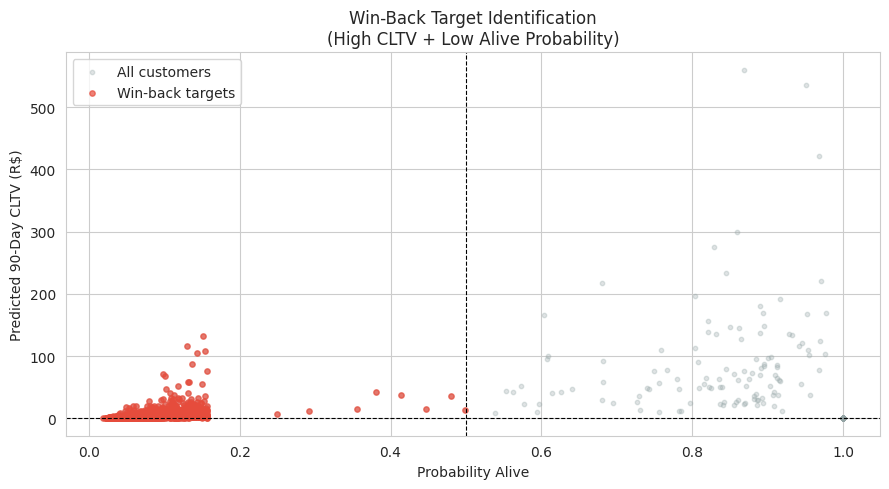

In [18]:
# Win-back targets: high predicted CLTV but low probability of being alive
# These are valuable customers who are at risk of leaving — worth saving
winback = rfm_cal_holdout[
    (rfm_cal_holdout['cltv_90d'] > rfm_cal_holdout['cltv_90d'].quantile(0.75)) &
    (rfm_cal_holdout['prob_alive'] < 0.5)
].copy()

winback = winback.sort_values('cltv_90d', ascending=False)

print(f'Win-back target customers: {len(winback)}')
print(f'Average CLTV of targets:   R$ {winback["cltv_90d"].mean():.2f}')
print(f'Average alive probability: {winback["prob_alive"].mean():.2%}')
print()
print('Top 10 Win-Back Targets:')
print(winback[['frequency_cal','monetary_value_cal','prob_alive','cltv_90d']].head(10).round(2))

# Visualise win-back segment
plt.figure(figsize=(9, 5))
plt.scatter(rfm_cal_holdout['prob_alive'], rfm_cal_holdout['cltv_90d'],
            alpha=0.3, color='#95a5a6', s=10, label='All customers')
plt.scatter(winback['prob_alive'], winback['cltv_90d'],
            alpha=0.7, color='#e74c3c', s=15, label='Win-back targets')
plt.axvline(x=0.5, color='black', linestyle='--', linewidth=0.8)
plt.axhline(y=rfm_cal_holdout['cltv_90d'].quantile(0.75), color='black', linestyle='--', linewidth=0.8)
plt.title('Win-Back Target Identification\n(High CLTV + Low Alive Probability)')
plt.xlabel('Probability Alive')
plt.ylabel('Predicted 90-Day CLTV (R$)')
plt.legend()
plt.tight_layout()
plt.show()